<a href="https://colab.research.google.com/github/Atharv-Chopade/Machine_Learning/blob/main/XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install xgboost

In [2]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X = data.data
y = data.target

In [3]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y ,test_size = 0.3 , random_state = 42)

In [12]:
from re import sub
from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators = 100 ,
    learning_rate = 0.1 ,
    max_depth = 3 ,
    subsample = 0.8 ,
    random_state = 4
)

In [13]:
model.fit(X_train , y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [14]:
y_pred  = model.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score , classification_report
print(classification_report(y_test , y_pred))
accuracy_score(y_test , y_pred) * 100

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        63
           1       0.97      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



96.49122807017544

In [17]:
import matplotlib.pyplot as plt

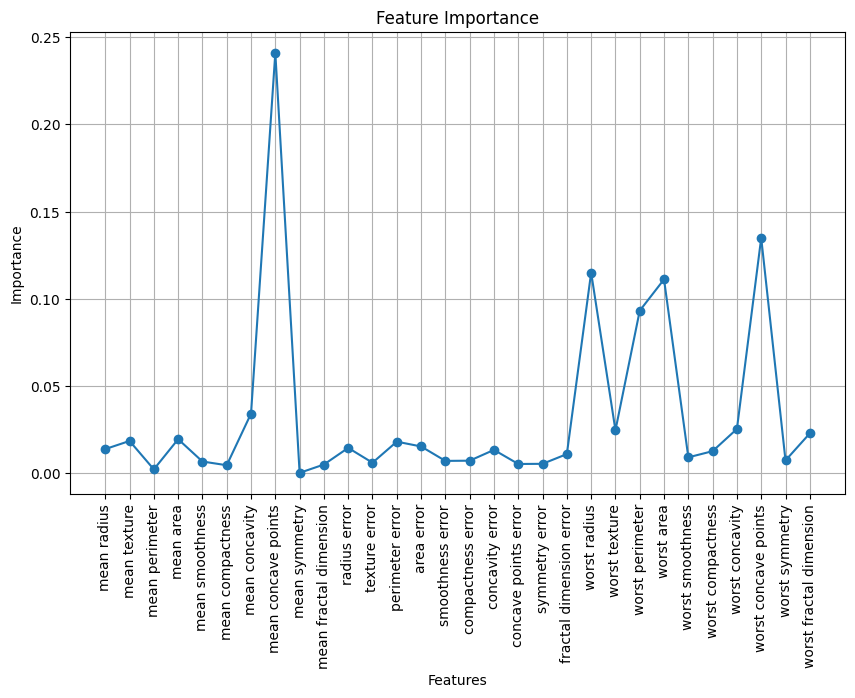

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(model.feature_importances_, marker='o')
plt.xticks(range(len(data.feature_names)), data.feature_names, rotation=90)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.grid(True)
plt.show()

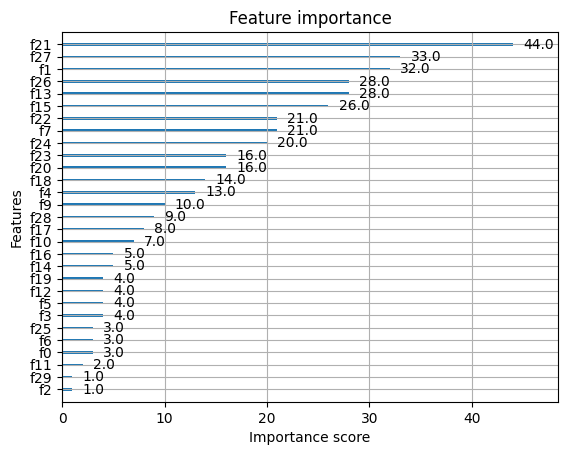

In [22]:
from xgboost import plot_importance
plot_importance(model)
plt.show()

Max depth = 3

In [25]:
depth = [3 , 6 , 12]
lr = [0.1 , 0.01 , 0.001]
subsamples = [0.6 , 0.8 , 1.0]

In [27]:
results = {
    'depth' : [] ,
    'learning_rate' : [] ,
    'subsample' : [] ,
    'accuracy' : []
}

In [28]:
for d in depth:
  for l in lr:
    for s in subsamples:
      model = XGBClassifier(
          n_estimators = 100 ,
          learning_rate = l ,
          max_depth = d ,
          subsample = s ,
          random_state = 4
      )
      model.fit(X_train , y_train)
      y_pred = model.predict(X_test)
      accuracy = accuracy_score(y_test , y_pred)
      results['depth'].append(d)
      results['learning_rate'].append(l)
      results['subsample'].append(s)
      results['accuracy'].append(accuracy)

In [29]:
import pandas as pd

In [30]:
df = pd.DataFrame(results)

In [32]:
df.shape

(27, 4)

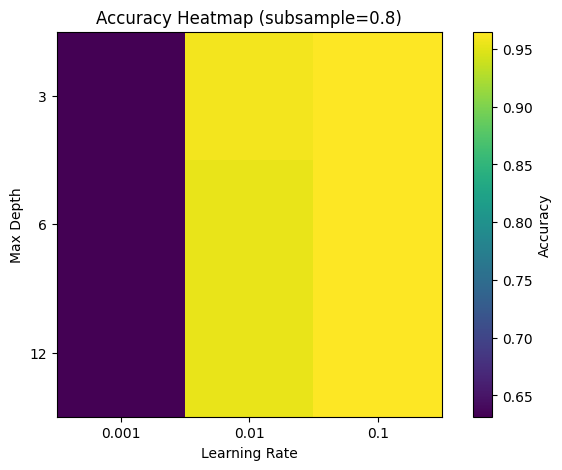

In [34]:

sub = df[df["subsample"] == 0.8]

pivot = sub.pivot(
    index="depth",
    columns="learning_rate",
    values="accuracy"
)

plt.figure(figsize=(8,5))
plt.imshow(pivot, cmap="viridis")

plt.colorbar(label="Accuracy")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.xlabel("Learning Rate")
plt.ylabel("Max Depth")
plt.title("Accuracy Heatmap (subsample=0.8)")

plt.show()

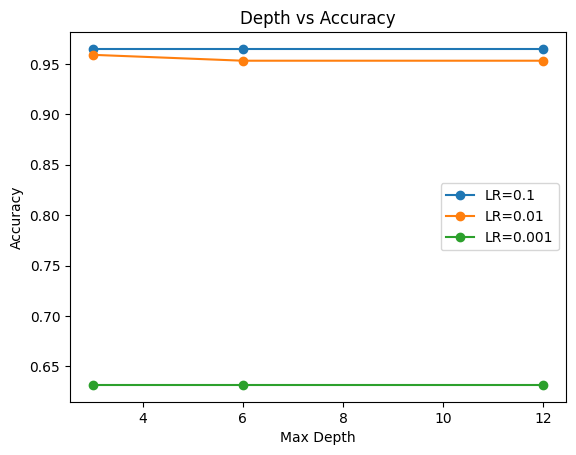

In [35]:

for lr in df["learning_rate"].unique():
    subset = df[
        (df["learning_rate"] == lr) &
        (df["subsample"] == 0.8)
    ]

    plt.plot(
        subset["depth"],
        subset["accuracy"],
        marker="o",
        label=f"LR={lr}"
    )

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Depth vs Accuracy")
plt.legend()

plt.show()

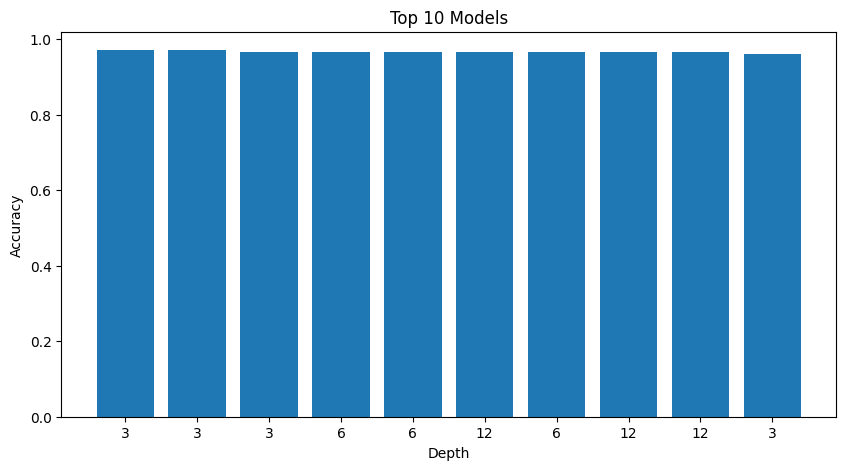

In [37]:
best = df.sort_values("accuracy", ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    range(len(best)),
    best["accuracy"]
)

plt.xticks(
    range(len(best)),
    best["depth"]
)

plt.xlabel("Depth")
plt.ylabel("Accuracy")
plt.title("Top 10 Models")

plt.show()

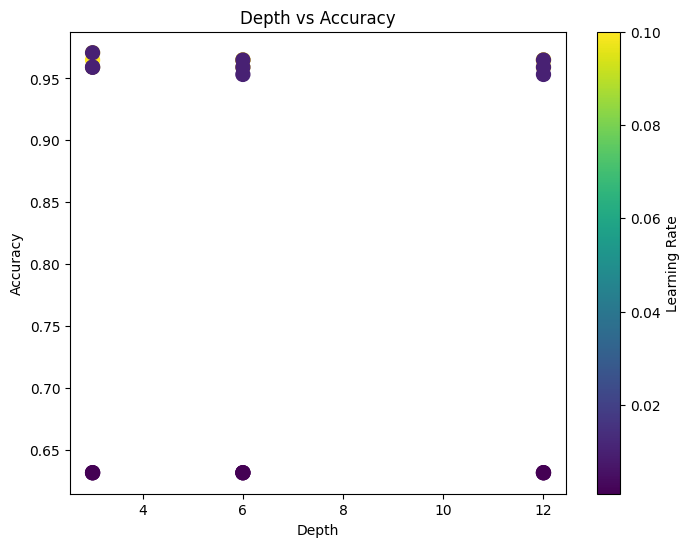

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["depth"],
    df["accuracy"],
    c=df["learning_rate"],
    s=100
)

plt.xlabel("Depth")
plt.ylabel("Accuracy")
plt.title("Depth vs Accuracy")

plt.colorbar(label="Learning Rate")

plt.show()

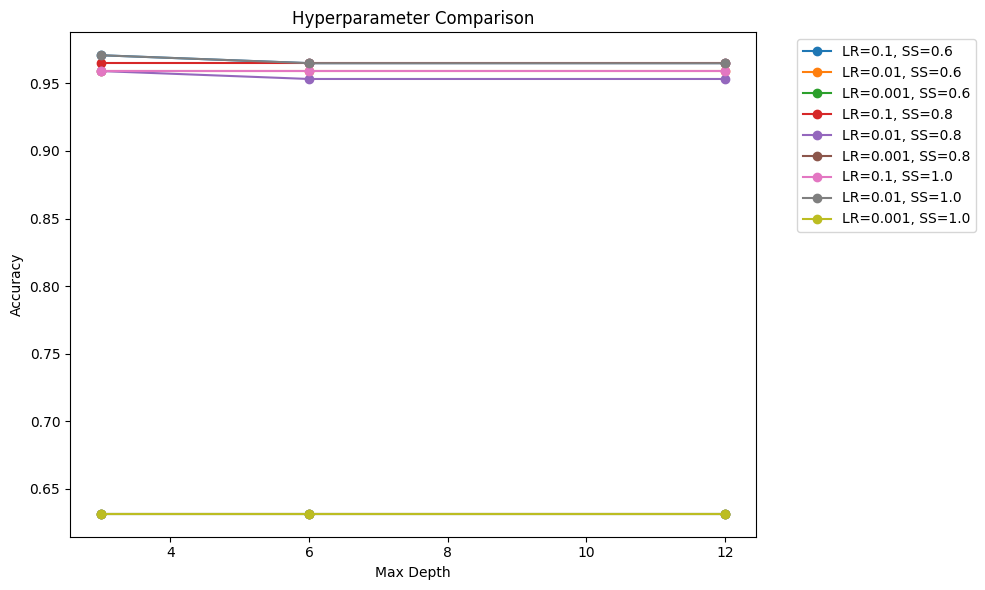

In [44]:
plt.figure(figsize=(10,6))

for subsample in df["subsample"].unique():
    for lr in df["learning_rate"].unique():

        subset = df[
            (df["subsample"] == subsample) &
            (df["learning_rate"] == lr)
        ]

        plt.plot(
            subset["depth"],
            subset["accuracy"],
            marker="o",
            label=f"LR={lr}, SS={subsample}"
        )

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Hyperparameter Comparison")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()